# Custom Isolation Forest with SHAP Explanations

## Import Libraries

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from isolation_forest import IsolationTreeEnsemble

## Load Dataset

In [148]:
df = pd.read_csv('../Data/unscaled_processed_airdata.csv')
df.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time,Hour,Day,weekday
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00,18,10,2
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00,19,10,2
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00,20,10,2
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00,21,10,2
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00,22,10,2


In [149]:
df.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,Day,weekday
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.130603,1103.059741,10.179155,942.142620,241.922197,832.758897,109.632094,1453.298814,1032.544298,18.233408,49.191386,1.019621,11.498557,15.876884,3.009939
std,1.431736,218.196346,7.503812,267.866611,204.315075,255.709833,46.462311,343.206131,404.447613,8.781791,17.194506,0.402203,6.923182,8.808653,2.000323
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,0.000000,1.000000,0.000000
25%,1.100000,938.000000,4.500000,736.000000,96.000000,654.000000,76.000000,1227.000000,733.000000,11.700000,35.800000,0.732300,5.000000,8.000000,1.000000
50%,1.800000,1067.000000,8.300000,910.012987,180.000000,804.000000,104.917526,1460.000000,970.000000,17.600000,49.600000,0.989500,11.000000,16.000000,3.000000
75%,2.900000,1239.000000,14.100000,1119.000000,326.000000,968.000000,136.314685,1668.000000,1293.000000,24.300000,62.300000,1.306700,18.000000,23.000000,5.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,23.000000,31.000000,6.000000


## Create Cyclical Time Features

In [150]:
df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['Day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['Day'] / 31)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

## Prepare Features

In [151]:
features_to_drop = ['Hour', 'Day', 'weekday', 'Date_Time']
df_features = df.drop(columns=features_to_drop)

## Train Isolation Forest

In [152]:
n_samples = df_features.shape[0]
sample_size = min(256, n_samples)
n_trees = 100

iso_forest = IsolationTreeEnsemble(sample_size=sample_size, n_trees=n_trees)
iso_forest.fit(df_features)

## Calculate Anomaly Scores

In [153]:
anomaly_scores = iso_forest.anomaly_score(df_features)
df['Anomaly_Score'] = anomaly_scores

In [154]:
contamination = 0.01
threshold = np.percentile(anomaly_scores, (1 - contamination) * 100)

predictions = iso_forest.predict_from_anomaly_scores(anomaly_scores, threshold)
df['Anomaly'] = predictions
df['Anomaly_Label'] = df['Anomaly'].apply(lambda x: -1 if x == 1 else 1)

print(f"Anomalies: {sum(df['Anomaly'] == 1)} ({sum(df['Anomaly'] == 1)/len(df)*100:.2f}%)")

Anomalies: 94 (1.00%)


## Anomaly Score Distribution

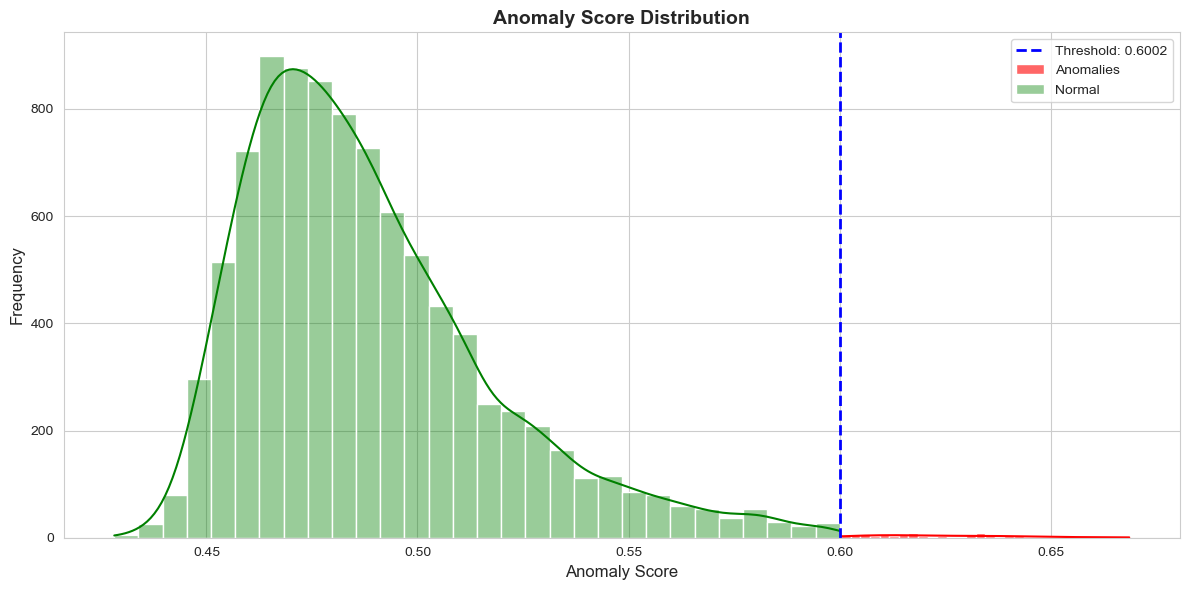

In [155]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Anomaly'] == 1]['Anomaly_Score'], bins=30, kde=True, 
             color='red', alpha=0.6, label='Anomalies')
sns.histplot(df[df['Anomaly'] == 0]['Anomaly_Score'], bins=30, kde=True, 
             color='green', alpha=0.4, label='Normal')
plt.axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.xlabel('Anomaly Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Anomaly Score Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


## Initialize SHAP Explainer

In [156]:
sample_for_shap = min(100, len(df_features))
df_shap_sample = df_features.sample(n=sample_for_shap, random_state=42)

def model_predict(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=df_features.columns)
    return iso_forest.anomaly_score(X)

explainer = shap.KernelExplainer(model_predict, df_shap_sample)

In [157]:
anomaly_indices = df[df['Anomaly'] == 1].index.tolist()
normal_indices = df[df['Anomaly'] == 0].index.tolist()

n_anomalies_sample = min(len(anomaly_indices), 25)
n_normal_sample = 25

selected_anomalies = np.random.choice(anomaly_indices, n_anomalies_sample, replace=False)
selected_normal = np.random.choice(normal_indices, n_normal_sample, replace=False)

shap_indices = np.concatenate([selected_anomalies, selected_normal])
df_shap_explain = df_features.iloc[shap_indices]

shap_values = explainer.shap_values(df_shap_explain, nsamples=100, silent=False)

  0%|          | 0/50 [00:00<?, ?it/s]

## Feature Importance: Anomalies vs Normal

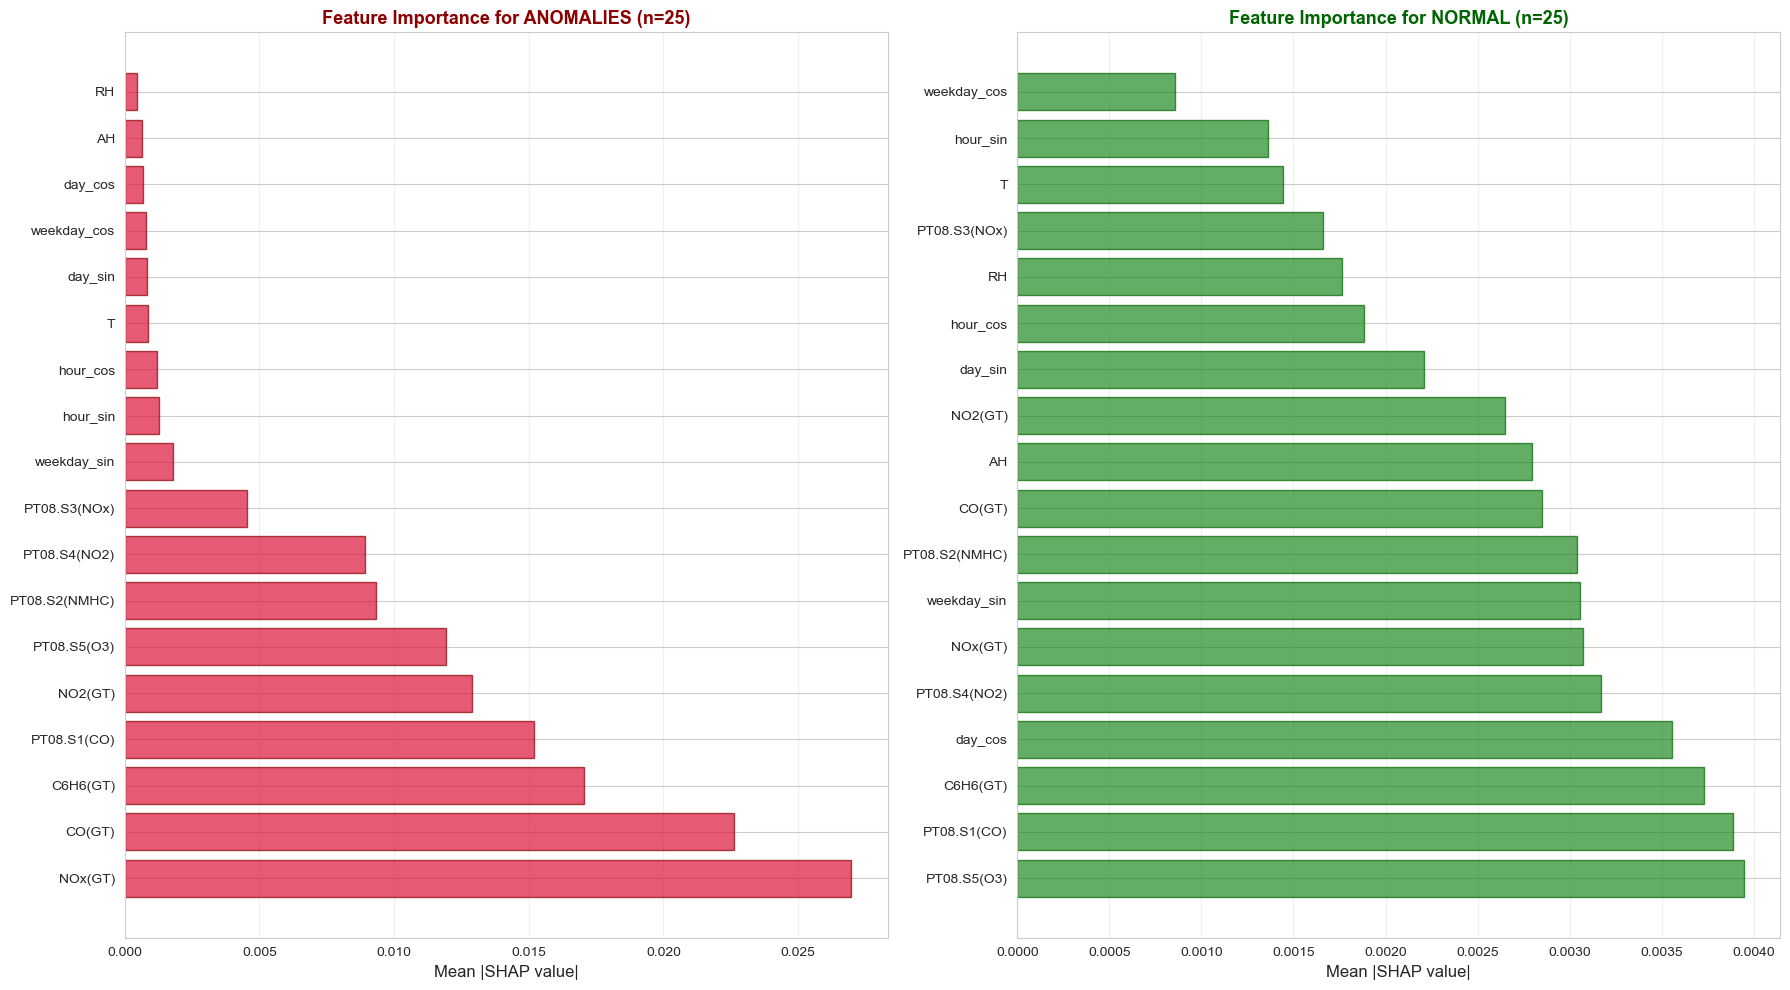

In [158]:
anomaly_mask_shap = df.iloc[shap_indices]['Anomaly'].values == 1
normal_mask_shap = df.iloc[shap_indices]['Anomaly'].values == 0

anomaly_shap_mean = np.abs(shap_values[anomaly_mask_shap]).mean(axis=0)
normal_shap_mean = np.abs(shap_values[normal_mask_shap]).mean(axis=0)

feature_names = list(df_features.columns)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

sorted_idx_anom = np.argsort(anomaly_shap_mean)[::-1]
axes[0].barh(range(len(feature_names)), anomaly_shap_mean[sorted_idx_anom], 
             color='crimson', alpha=0.7, edgecolor='darkred')
axes[0].set_yticks(range(len(feature_names)))
axes[0].set_yticklabels([feature_names[i] for i in sorted_idx_anom])
axes[0].set_xlabel('Mean |SHAP value|', fontsize=12)
axes[0].set_title(f'Feature Importance for ANOMALIES (n={sum(anomaly_mask_shap)})', 
                  fontsize=13, fontweight='bold', color='darkred')
axes[0].grid(axis='x', alpha=0.3)

sorted_idx_norm = np.argsort(normal_shap_mean)[::-1]
axes[1].barh(range(len(feature_names)), normal_shap_mean[sorted_idx_norm], 
             color='forestgreen', alpha=0.7, edgecolor='darkgreen')
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_yticklabels([feature_names[i] for i in sorted_idx_norm])
axes[1].set_xlabel('Mean |SHAP value|', fontsize=12)
axes[1].set_title(f'Feature Importance for NORMAL (n={sum(normal_mask_shap)})', 
                  fontsize=13, fontweight='bold', color='darkgreen')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Differential Feature Importance

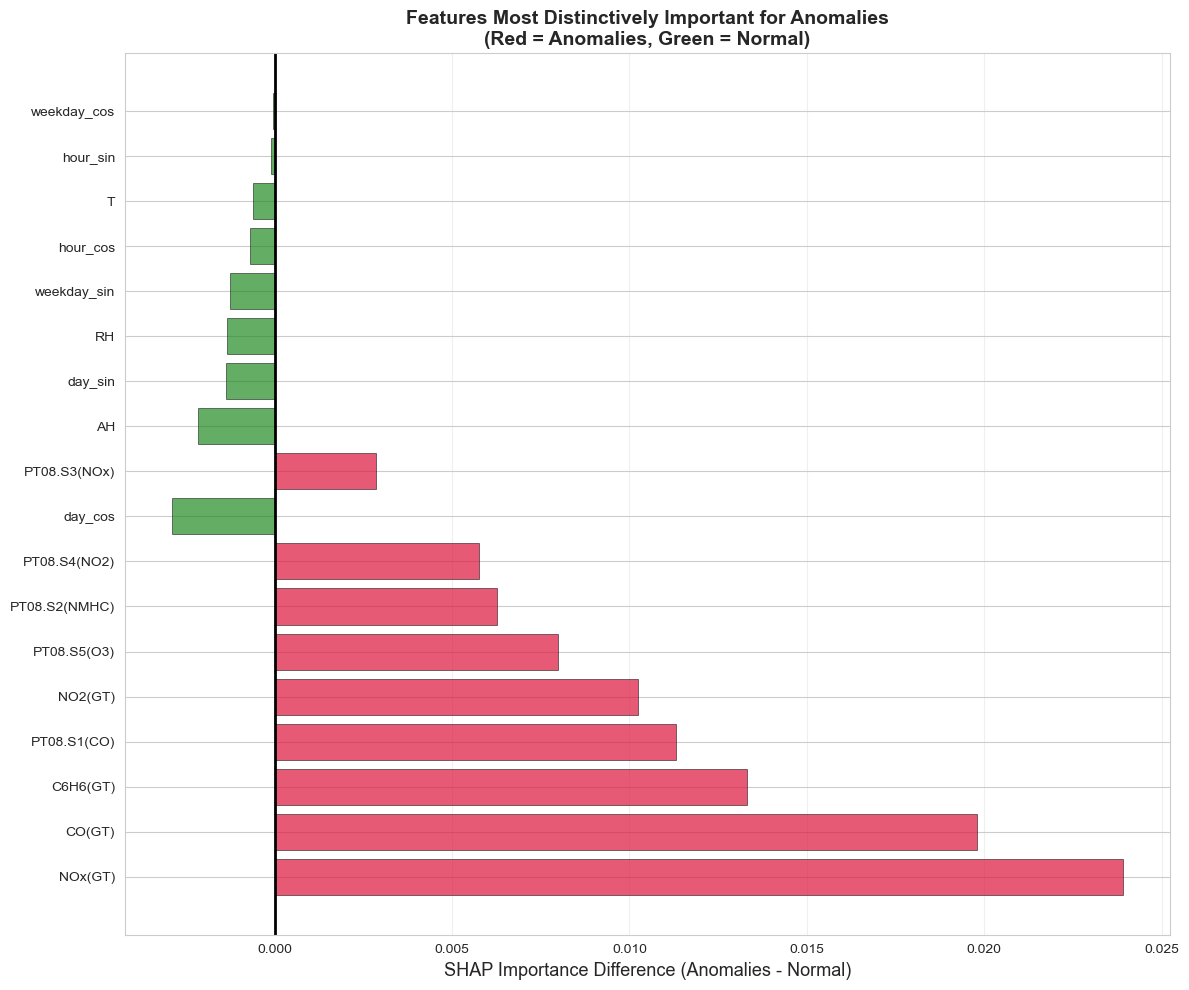

In [159]:
shap_difference = anomaly_shap_mean - normal_shap_mean
sorted_idx_diff = np.argsort(np.abs(shap_difference))[::-1]

plt.figure(figsize=(12, 10))
colors = ['crimson' if x > 0 else 'forestgreen' for x in shap_difference[sorted_idx_diff]]
plt.barh(range(len(feature_names)), shap_difference[sorted_idx_diff], 
         color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx_diff])
plt.xlabel('SHAP Importance Difference (Anomalies - Normal)', fontsize=13)
plt.title('Features Most Distinctively Important for Anomalies\n(Red = Anomalies, Green = Normal)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## SHAP Summary Plots

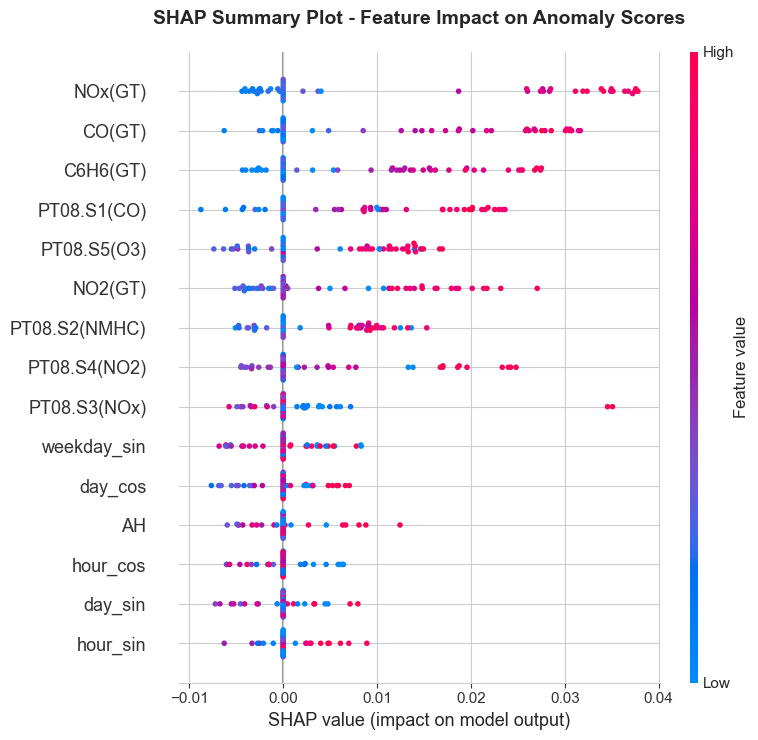

In [160]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, df_shap_explain, max_display=15, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Anomaly Scores', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

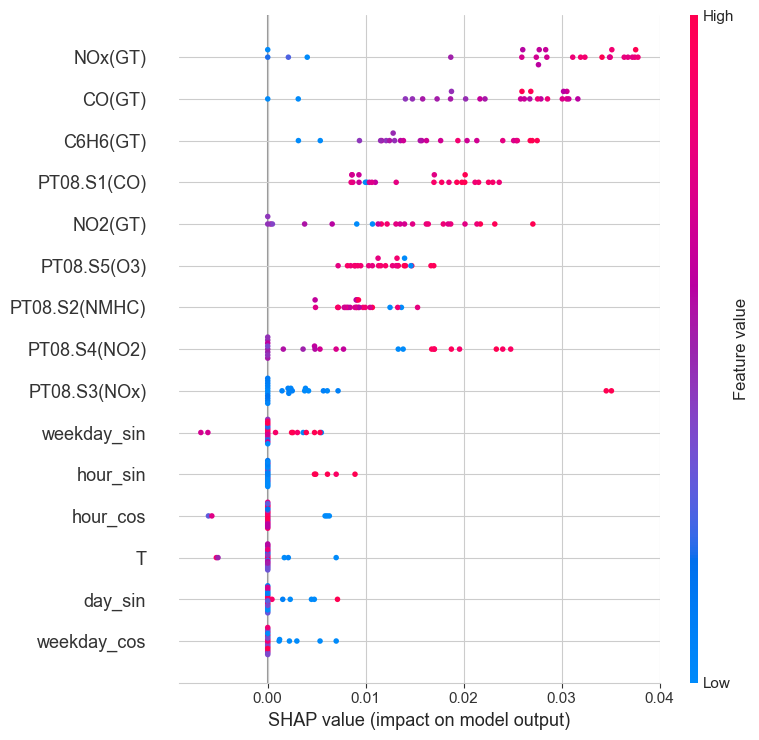

In [161]:
if sum(anomaly_mask_shap) > 0:
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values[anomaly_mask_shap], 
                     df_shap_explain.iloc[anomaly_mask_shap], 
                     max_display=15,
                     show=False)
    plt.tight_layout()
    plt.show()

## Individual Instance Analysis

In [162]:
sample_scores = df.iloc[shap_indices]['Anomaly_Score'].values
sample_predictions = df.iloc[shap_indices]['Anomaly'].values

anomaly_sample_indices = np.where(sample_predictions == 1)[0]
most_anomalous_local_idx = anomaly_sample_indices[np.argmax(sample_scores[anomaly_sample_indices])] if len(anomaly_sample_indices) > 0 else None
most_anomalous_score = sample_scores[most_anomalous_local_idx] if most_anomalous_local_idx is not None else None

normal_sample_indices = np.where(sample_predictions == 0)[0]
most_normal_local_idx = normal_sample_indices[np.argmin(sample_scores[normal_sample_indices])] if len(normal_sample_indices) > 0 else None
most_normal_score = sample_scores[most_normal_local_idx] if most_normal_local_idx is not None else None

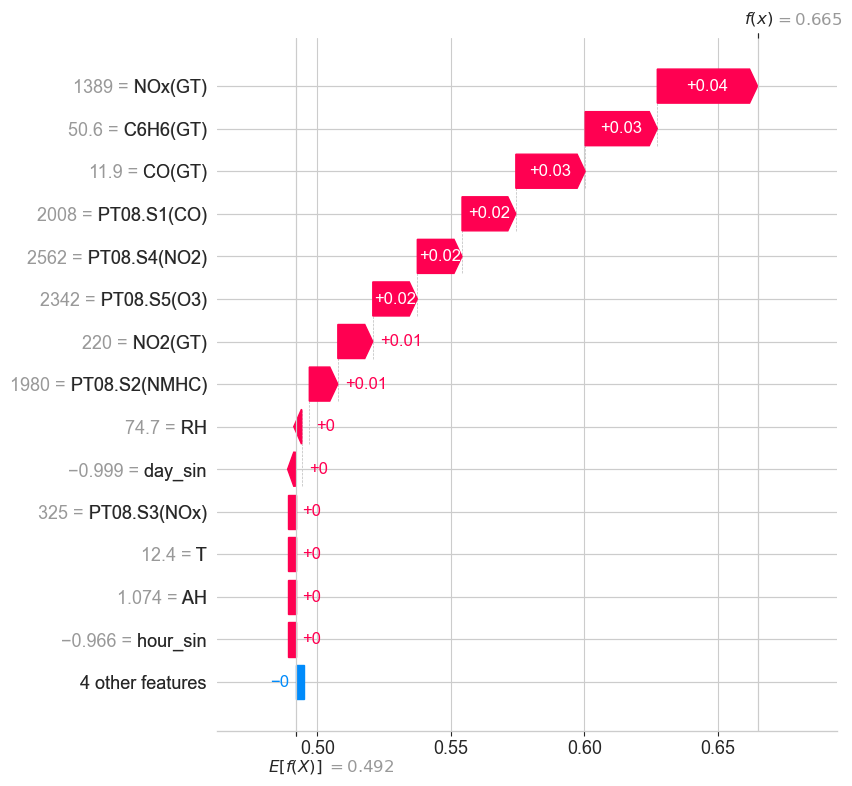

In [163]:
if most_anomalous_local_idx is not None:
    shap_exp = shap.Explanation(values=shap_values[most_anomalous_local_idx],
                                base_values=explainer.expected_value,
                                data=df_shap_explain.iloc[most_anomalous_local_idx].values,
                                feature_names=list(df_features.columns))
    shap.waterfall_plot(shap_exp, max_display=15)

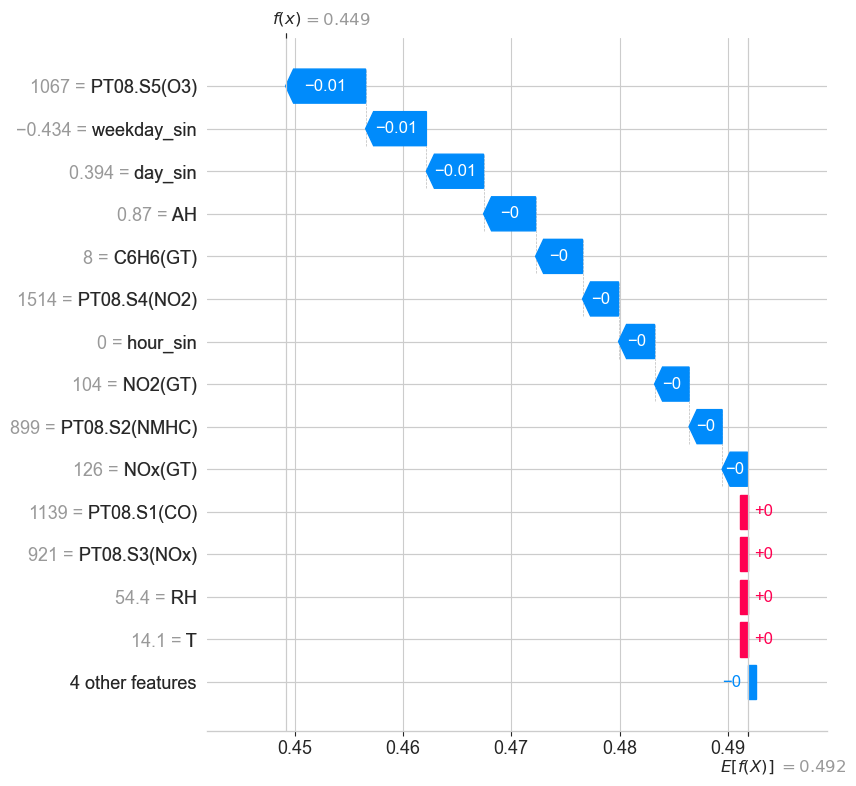

In [164]:
if most_normal_local_idx is not None:
    shap_exp = shap.Explanation(values=shap_values[most_normal_local_idx],
                                base_values=explainer.expected_value,
                                data=df_shap_explain.iloc[most_normal_local_idx].values,
                                feature_names=list(df_features.columns))
    shap.waterfall_plot(shap_exp, max_display=15)

## Anomalies Over Time

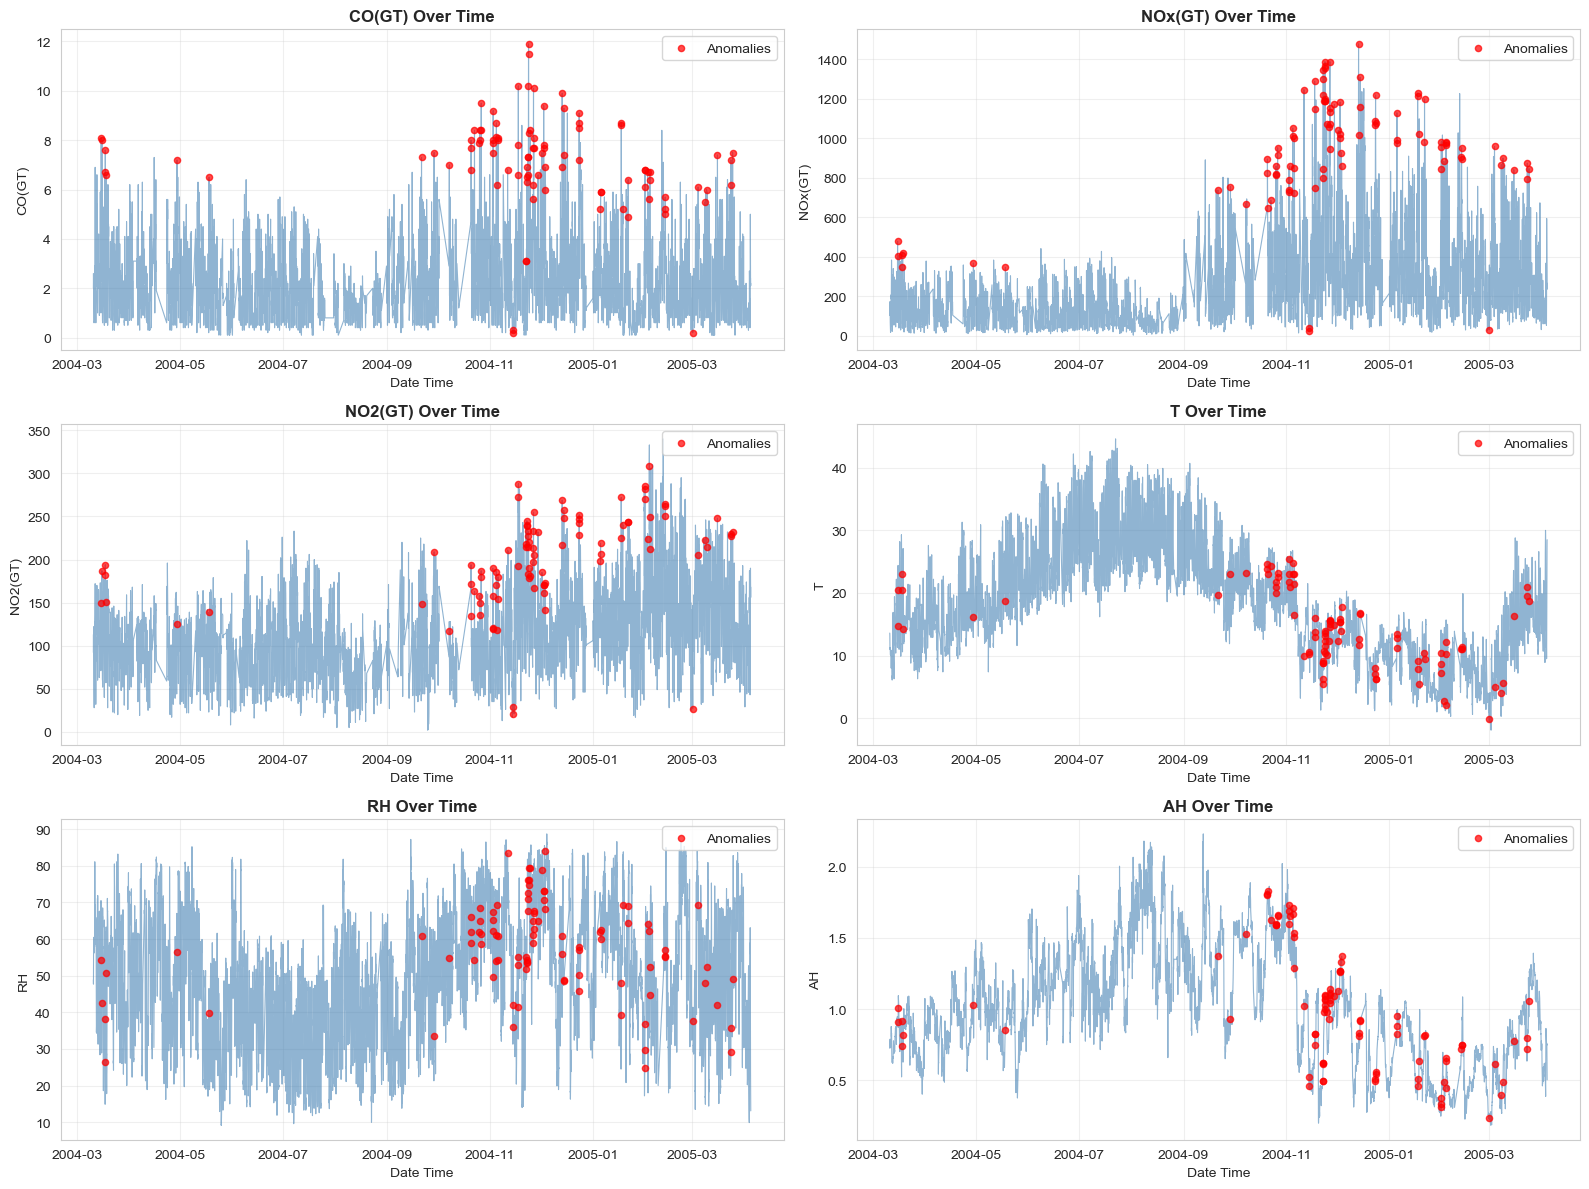

In [165]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

key_features = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']
anomalies = df[df['Anomaly'] == 1]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if feature in df.columns:
        axes[i].plot(df['Date_Time'], df[feature], alpha=0.6, linewidth=0.8, color='steelblue')
        axes[i].scatter(anomalies['Date_Time'], anomalies[feature], 
                       color='red', s=20, alpha=0.7, label='Anomalies', zorder=5)
        axes[i].set_xlabel('Date Time', fontsize=10)
        axes[i].set_ylabel(feature, fontsize=10)
        axes[i].set_title(f'{feature} Over Time', fontsize=12, fontweight='bold')
        axes[i].legend(loc='upper right')
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()